### Read the Snow17 and SNOWPACK Test1/ Output and Compare with Obs: PPSA2

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/ppsa2'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
ds_hrrrak_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa2/output/hrrrak_ppsa2_WY2025_base.smet")
ds_met_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa2/output/met_hrrrak_ppsa2_WY2025_base_with_met_station.smet")


print(ds_hrrrak_snowpack)
print(header)

<xarray.Dataset> Size: 3MB
Dimensions:               (timestamp: 6548)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 52kB 2024-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 52kB 266.5 266.7 ... 10.89 6.916
    Ql                    (timestamp) float64 52kB 189.9 223.6 ... 11.0 7.244
    Qg                    (timestamp) float64 52kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 52kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 52kB -999.0 -999.0 ... -999.0
    Qr                    (timestamp) float64 52kB 4.095 2.344 ... 3.203 0.0
    ...                    ...
    zSs                   (timestamp) float64 52kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Ss                    (timestamp) float64 52kB 6.0 6.0 6.0 ... 6.0 6.0 6.0
    zS4                   (timestamp) float64 52kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S4                    (timestamp) float64 52kB 6.0 6.0 6.0 ... 6.0 6.0 

/tmp/ipykernel_1843484/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1843484/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


### Open PPSA2 Station Observations

In [5]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_met_raw = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met_raw['datetime'] = pd.to_datetime(df_met_raw['utc_valid'], utc=True)
df_met_raw = df_met_raw.set_index('datetime')

# quick clean 
df_met = df_met_raw.copy()
df_met['hs'] = df_met['SDIRZZZ'].where(
    (df_met['SDIRZZZ'] >= 0) & (df_met['SDIRZZZ'] <= 200)
)

df_met = df_met.loc['2024-10-01':'2025-10-10', ['hs']]

# The raw data is in inches, convert to cm
df_met = df_met * 2.54

df_met

,hs
datetime,
2024-10-01 00:00:00+00:00,43.1038
2024-10-01 01:00:00+00:00,42.1132
2024-10-01 02:00:00+00:00,42.8752
2024-10-01 03:00:00+00:00,41.0972
2024-10-01 04:00:00+00:00,43.6626
...,...
2025-05-31 20:00:00+00:00,41.8592
2025-05-31 21:00:00+00:00,40.8178
2025-05-31 22:00:00+00:00,42.5704


In [6]:
# Clean it up: Apply masks for specific months and thresholds
# October: if hs > 50, set to NaN
mask_oct = (df_met.index.month == 10) & (df_met['hs'] > 25)
df_met.loc[mask_oct, 'hs'] = np.nan

# October and November and December: if hs < 5, set to NaN
mask_oct_nov = (df_met.index.month.isin([10, 11, 12])) & (df_met['hs'] < 5)
df_met.loc[mask_oct_nov, 'hs'] = np.nan

# February, March, April, May: if hs > 200, set to NaN
mask_feb_may = (df_met.index.month.isin([2, 3, 4, 5])) & (df_met['hs'] > 200)
df_met.loc[mask_feb_may, 'hs'] = np.nan

# Optional: Print summary of changes
print(f"October values set to NaN: {mask_oct.sum()}")
print(f"Feb-May values set to NaN: {mask_feb_may.sum()}")
print(f"Total NaN values in 'hs': {df_met['hs'].isna().sum()}")

October values set to NaN: 286
Feb-May values set to NaN: 32
Total NaN values in 'hs': 984


Text(0, 0.5, 'snow depth (cm)')

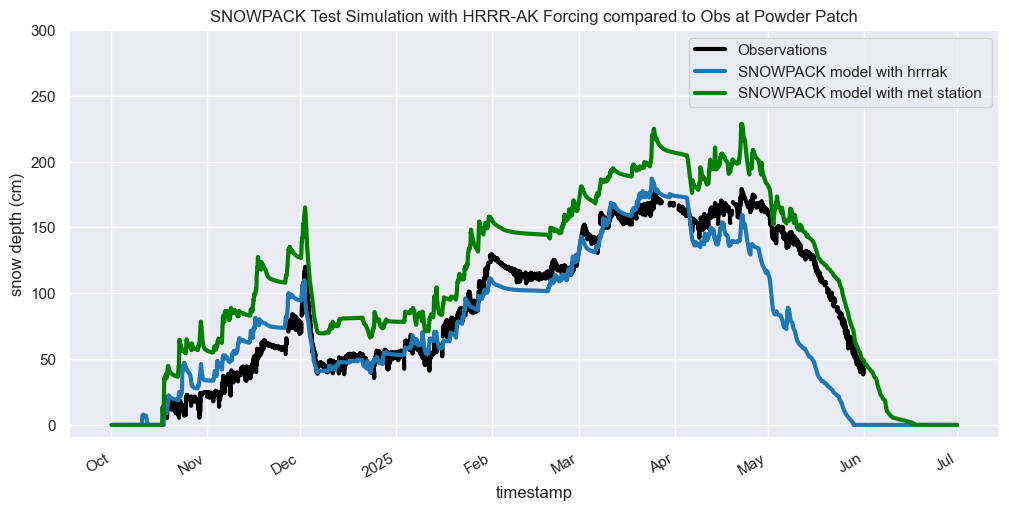

In [7]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color='black')
ds_hrrrak_snowpack.HS_mod.plot(label = 'SNOWPACK model with hrrrak', linewidth = 3, color='tab:blue')
ds_met_snowpack.HS_mod.plot(label = 'SNOWPACK model with met station ', linewidth = 3, color='green')

plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Powder Patch')
plt.legend()

plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

### Open Snow-17 Output 

In [8]:
# /home/cassie/python/models/run_snow17/test1/output/output.snow17bmi.hrrrak_ppsa2_test1.txt
filepath = '/home/cassie/python/models/run_snow17/sites/ppsa2/output/'
filename = 'output.snow17bmi.hrrrak_ppsa2_WY2025.txt'

fullpath = os.path.join(filepath, filename)

# df_snow17_hrrrak = pd.read_csv(fullpath) # use delimiter = '\t' or ',' if comma-separated 
df_snow17_hrrrak = pd.read_csv(fullpath, sep=r'\s+', header=0) # using delim_whitespaced worked for the header, this is needed for the data to separate correctly

# change the name 'mo' to 'month, 'dy' to 'day', 'hr' to 'hour'
df_snow17_hrrrak.rename(columns={'mo':'month', 'dy':'day', 'hr':'hour'}, inplace=True)
df_snow17_hrrrak.head()

# now, create a datetime object from the year, month, day, hour, minute columns
df_snow17_hrrrak['datetime'] = pd.to_datetime(df_snow17_hrrrak[['year', 'month', 'day', 'hour']])
# index by datetime 
df_snow17_hrrrak.set_index('datetime', inplace=True)
df_snow17_hrrrak.head()

,year,month,day,hour,tair,precip,precip*scf,sneqv,snowh,raim
datetime,,,,,,,,,,
2024-10-01 05:00:00,2024,10,1,5,4.77,0.936,1.685,0.0,0.0,0.936
2024-10-01 06:00:00,2024,10,1,6,5.07,0.504,0.907,0.0,0.0,0.504
2024-10-01 07:00:00,2024,10,1,7,5.50,0.216,0.389,0.0,0.0,0.216
2024-10-01 08:00:00,2024,10,1,8,4.96,0.000,0.000,0.0,0.0,0.000
2024-10-01 09:00:00,2024,10,1,9,4.86,0.324,0.583,0.0,0.0,0.324


In [9]:
# /home/cassie/python/models/run_snow17/test1/output/output.snow17bmi.hrrrak_ppsa2_test1.txt
filepath = '/home/cassie/python/models/run_snow17/sites/ppsa2/output/'
filename = 'output.snow17bmi.met_ppsa2_WY2025.txt'

fullpath = os.path.join(filepath, filename)

# df_snow17_met = pd.read_csv(fullpath) # use delimiter = '\t' or ',' if comma-separated 
df_snow17_met = pd.read_csv(fullpath, sep=r'\s+', header=0) # using delim_whitespaced worked for the header, this is needed for the data to separate correctly

# change the name 'mo' to 'month, 'dy' to 'day', 'hr' to 'hour'
df_snow17_met.rename(columns={'mo':'month', 'dy':'day', 'hr':'hour'}, inplace=True)
df_snow17_met.head()

# now, create a datetime object from the year, month, day, hour, minute columns
df_snow17_met['datetime'] = pd.to_datetime(df_snow17_met[['year', 'month', 'day', 'hour']])
# index by datetime 
df_snow17_met.set_index('datetime', inplace=True)
df_snow17_met.head()

,year,month,day,hour,tair,precip,precip*scf,sneqv,snowh,raim
datetime,,,,,,,,,,
2024-10-01 05:00:00,2024,10,1,5,2.89,0.936,1.685,0.0,0.0,0.936
2024-10-01 06:00:00,2024,10,1,6,3.06,0.504,0.907,0.0,0.0,0.504
2024-10-01 07:00:00,2024,10,1,7,3.44,0.216,0.389,0.0,0.0,0.216
2024-10-01 08:00:00,2024,10,1,8,3.94,0.000,0.000,0.0,0.0,0.000
2024-10-01 09:00:00,2024,10,1,9,4.28,0.324,0.583,0.0,0.0,0.324


# Plot all together

Snow depth from Snow-17 looks like it's in meters, so multiply by 100

Text(0, 0.5, 'snow depth (cm)')

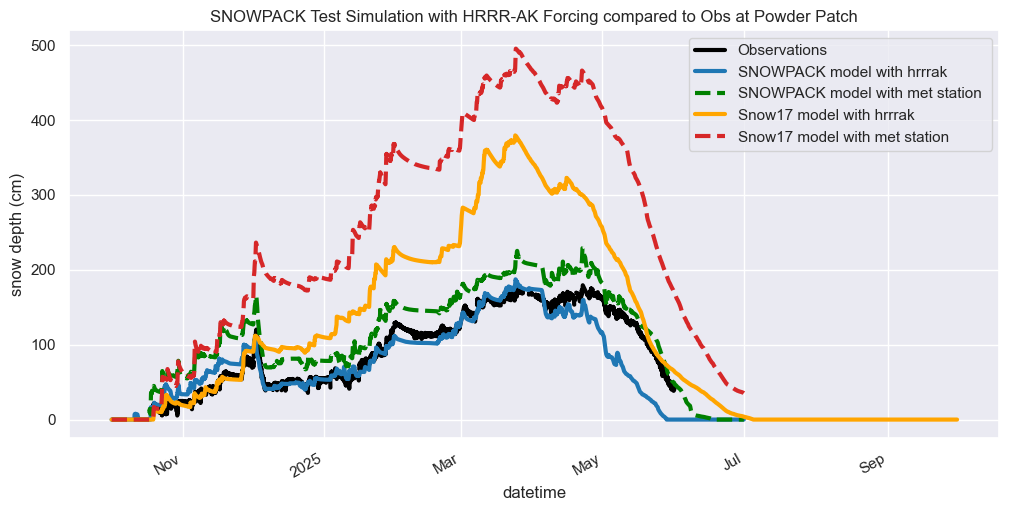

In [15]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color='black')
ds_hrrrak_snowpack.HS_mod.plot(label = 'SNOWPACK model with hrrrak', linewidth = 3, color='tab:blue')
ds_met_snowpack.HS_mod.plot(label = 'SNOWPACK model with met station ', linewidth = 3, color='green', linestyle='--')

(df_snow17_hrrrak.snowh*100).plot(label = 'Snow17 model with hrrrak', linewidth = 3, color='orange')
(df_snow17_met.snowh*100).plot(label = 'Snow17 model with met station', linewidth = 3, color='tab:red', linestyle='--')



plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

If we multiply it by a factor of something, like 20/50, 

Text(0, 0.5, 'snow depth (cm)')

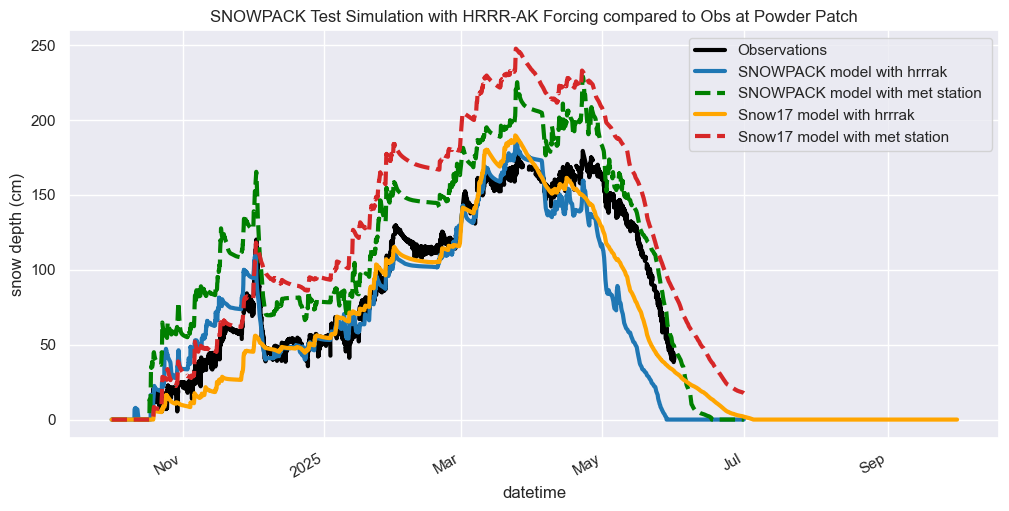

In [14]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color='black')
ds_hrrrak_snowpack.HS_mod.plot(label = 'SNOWPACK model with hrrrak', linewidth = 3, color='tab:blue')
ds_met_snowpack.HS_mod.plot(label = 'SNOWPACK model with met station ', linewidth = 3, color='green', linestyle='--')
(df_snow17_hrrrak.snowh*50).plot(label = 'Snow17 model with hrrrak', linewidth = 3, color='orange')
(df_snow17_met.snowh*50).plot(label = 'Snow17 model with met station', linewidth = 3, color='tab:red', linestyle='--')



plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

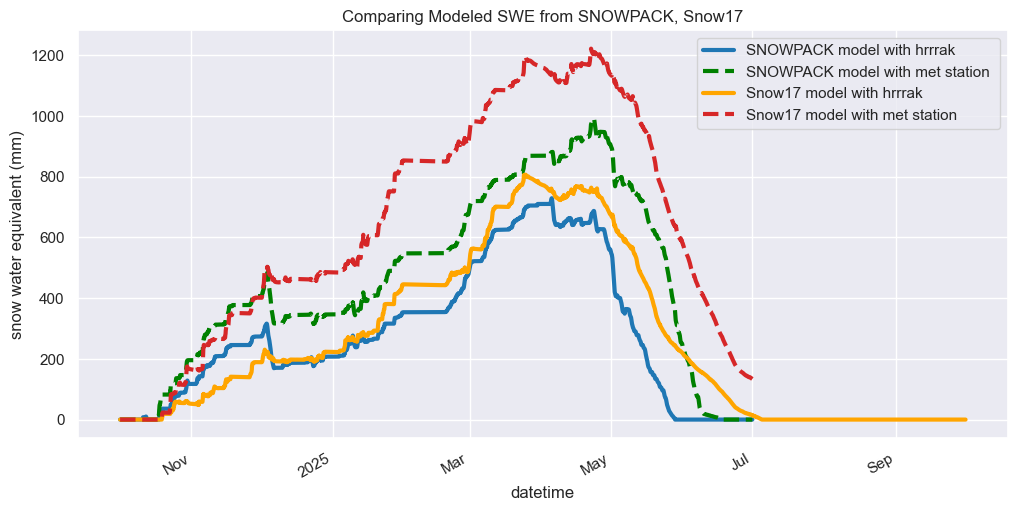

In [13]:
# SWE
ds_hrrrak_snowpack.SWE.plot(label = 'SNOWPACK model with hrrrak', linewidth = 3, color='tab:blue')
ds_met_snowpack.SWE.plot(label = 'SNOWPACK model with met station ', linewidth = 3, color='green', linestyle='--')

(df_snow17_hrrrak.sneqv).plot(label = 'Snow17 model with hrrrak', linewidth = 3, color='orange')
(df_snow17_met.sneqv).plot(label = 'Snow17 model with met station', linewidth = 3, color='tab:red', linestyle='--')

plt.title('Comparing Modeled SWE from SNOWPACK, Snow17')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow water equivalent (mm)')
plt.show()